In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
import warnings
warnings.filterwarnings('ignore')

# Set tema visual dasar
sns.set_theme(style="whitegrid")


In [2]:
# 1. Load Dataset
path = r'D:\\ARFI\\Kuliah\\Project\\satria-water-quality-ews\\data\raw\\Recalculated_Aquaculture_Water_Suitability_Signals_WQI_Derived.csv'
dataset = pd.read_csv(path)
print(f'Shape: {dataset.shape}')
display(dataset.head())


Shape: (4300, 21)


,Record ID,Temperature,Turbidity (cm),Dissolved Oxygen (mg L-1),Biochemical Oxygen Demand (mg L-1),Carbon Dioxide (mg L-1),pH,Total Alkalinity (mg L-1 as CaCO3),Total Hardness (mg L-1 as CaCO3),Calcium (mg L-1),...,Ammonia (mg L-1),Nitrite (mg L-1),Phosphorus (mg L-1),Hydrogen Sulphide (mg L-1),Plankton Abundance (No. L-1),Water Quality Index (WQI),WQI-Derived Quality Label,WQI-Derived Quality Category,WQI-Derived Aquaculture Suitability Classification,WQI-Derived Aquaculture Suitability Description
0,1,31.200,13.535,0.222,6.393,8.077,6.703,240.671,645.052,152.765,...,0.929,0.094,0.200,0.040,2190,54.10,3,Poor/Marginal,Restricted / Stressed,Reduced Suitability: Water is significantly im...
1,2,31.066,42.971,3.475,7.121,9.950,6.457,281.103,710.607,164.371,...,0.644,0.072,0.200,0.027,558,74.81,2,Good/Marginal,Suitable,Standard Suitability: Water is generally safe ...
2,3,31.090,41.791,3.764,7.541,3.201,8.220,242.452,601.083,140.578,...,1.963,0.099,0.200,0.040,2001,69.90,3,Poor/Marginal,Restricted / Stressed,Reduced Suitability: Water is significantly im...
3,4,15.241,10.005,3.339,6.615,9.187,6.714,275.743,132.707,8.577,...,1.828,0.086,0.391,0.028,804,69.16,3,Poor/Marginal,Restricted / Stressed,Reduced Suitability: Water is significantly im...
4,5,31.077,10.726,0.556,7.654,3.121,8.252,265.220,524.329,116.310,...,1.703,0.097,0.432,0.038,718,48.57,4,Very Poor/Unsuitable,Unsuitable / Critical,"Critical Risk: Water is heavily contaminated, ..."


In [3]:
# 2. Definisi Target dan Kolom Drop
target_col = 'WQI-Derived Aquaculture Suitability Classification'
cols_to_drop = [
    'Record ID', 'Water Quality Index (WQI)', 'WQI-Derived Quality Label', 
    'WQI-Derived Quality Category', 'WQI-Derived Aquaculture Suitability Description'
]

X = dataset.drop(columns=cols_to_drop + [target_col])
y = dataset[target_col]

# 3. Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(le.classes_)

class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Mapping Target: {class_mapping}")

# Binarisasi target untuk keperluan visualisasi ROC-AUC Multi-class
y_bin = label_binarize(y_encoded, classes=range(n_classes))

# 4. Train-Test Split tersinkronisasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
_, _, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Dimensi X_train: {X_train.shape} | Dimensi X_test: {X_test.shape}")

Mapping Target: {'Highly Suitable': np.int64(0), 'Restricted / Stressed': np.int64(1), 'Suitable': np.int64(2), 'Unsuitable / Critical': np.int64(3)}
Dimensi X_train: (3440, 15) | Dimensi X_test: (860, 15)


# Model Training & Evalution

In [4]:
import mlflow
import mlflow.sklearn
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc
from sklearn.model_selection import learning_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

## Baseline

In [5]:
from sklearn.preprocessing import RobustScaler
import mlflow
import mlflow.sklearn
import time
from sklearn.pipeline import Pipeline # Menggunakan Pipeline standar Scikit-Learn (lebih ringan)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Konfigurasi MLflow Server
mlflow.set_tracking_uri('http://127.0.0.1:5000')
mlflow.set_experiment('aq-water-quality-classification')

# Injeksi class_weight='balanced' ke dalam model
models_to_compare = {
    "LogisticRegression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, n_jobs=-1),
    "DecisionTree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "RandomForest": RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
}

print("=== Modul Pelatihan: Melatih 5 Model Baseline (Mode Class Weight) ===\n")

# Dictionary untuk menyimpan model dan hasil prediksi (digunakan di visualisasi nanti)
trained_pipelines = {}
model_predictions = {}
model_probabilities = {}
model_scores = {}

for model_name, classifier in models_to_compare.items():
    # Menambahkan tag _ClassWeight pada nama run agar tidak tertukar di MLflow UI
    with mlflow.start_run(run_name=f"Baseline_{model_name}_ClassWeight"):
        
        print(f"Sedang melatih {model_name}...")
        
        # Mulai pencatatan waktu
        start_time = time.time()
        
        # Inisialisasi Pipeline Murni (Tanpa SMOTE)
        pipeline = Pipeline([
            ('scaler', RobustScaler()), # Diaktifkan kembali, penting untuk Logistic Regression
            ('classifier', classifier)
        ])
        
        # Latih model
        pipeline.fit(X_train, y_train)
        
        # Hitung waktu training
        training_time = time.time() - start_time
        
        # Lakukan prediksi
        y_pred = pipeline.predict(X_test)
        y_score = pipeline.predict_proba(X_test)
        
        # Simpan hasil ke memori untuk visualisasi nanti
        trained_pipelines[model_name] = pipeline
        model_predictions[model_name] = y_pred
        model_probabilities[model_name] = y_score
        
        # Kalkulasi Metrik
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        model_scores[model_name] = f1_macro
        
        # Logging ke MLflow
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("imbalance_handling", "class_weight") # Pencatatan metode penanganan imbalance
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_macro", f1_macro)
        mlflow.log_metric("training_time_seconds", training_time) 
        mlflow.sklearn.log_model(pipeline, f"model_{model_name}")
        
        print(f" -> Selesai. F1: {f1_macro:.4f} | Waktu Latih: {training_time:.2f} detik")

print("\nPelatihan selesai. Model tersimpan di memori.")

2026/06/10 03:53:10 INFO mlflow.tracking.fluent: Experiment with name 'aq-water-quality-classification' does not exist. Creating a new experiment.


=== Modul Pelatihan: Melatih 5 Model Baseline (Mode Class Weight) ===

Sedang melatih LogisticRegression...


2026/06/10 03:53:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/10 03:53:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 -> Selesai. F1: 0.8759 | Waktu Latih: 3.47 detik
🏃 View run Baseline_LogisticRegression_ClassWeight at: http://127.0.0.1:5000/#/experiments/1/runs/ff25963ce2dc4b589b7707f0d3a71dab
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Sedang melatih DecisionTree...


2026/06/10 03:53:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/10 03:53:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 -> Selesai. F1: 0.9526 | Waktu Latih: 0.03 detik
🏃 View run Baseline_DecisionTree_ClassWeight at: http://127.0.0.1:5000/#/experiments/1/runs/a41e56d7d6da4eefbafd3b3ca20c354a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Sedang melatih RandomForest...


2026/06/10 03:53:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/10 03:53:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 -> Selesai. F1: 0.8848 | Waktu Latih: 0.29 detik
🏃 View run Baseline_RandomForest_ClassWeight at: http://127.0.0.1:5000/#/experiments/1/runs/f28836ff7e95479d9ebec3f0fd4399c3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Sedang melatih LightGBM...


2026/06/10 03:53:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/10 03:53:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 -> Selesai. F1: 0.9739 | Waktu Latih: 0.70 detik
🏃 View run Baseline_LightGBM_ClassWeight at: http://127.0.0.1:5000/#/experiments/1/runs/5dfb9b18295944e5a2163649f687c637
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

Pelatihan selesai. Model tersimpan di memori.


=== Modul Visualisasi: Membuat Dashboard Learning Curve ===

Dashboard disimpan di mlflow_plots/baseline_learning_curves.png


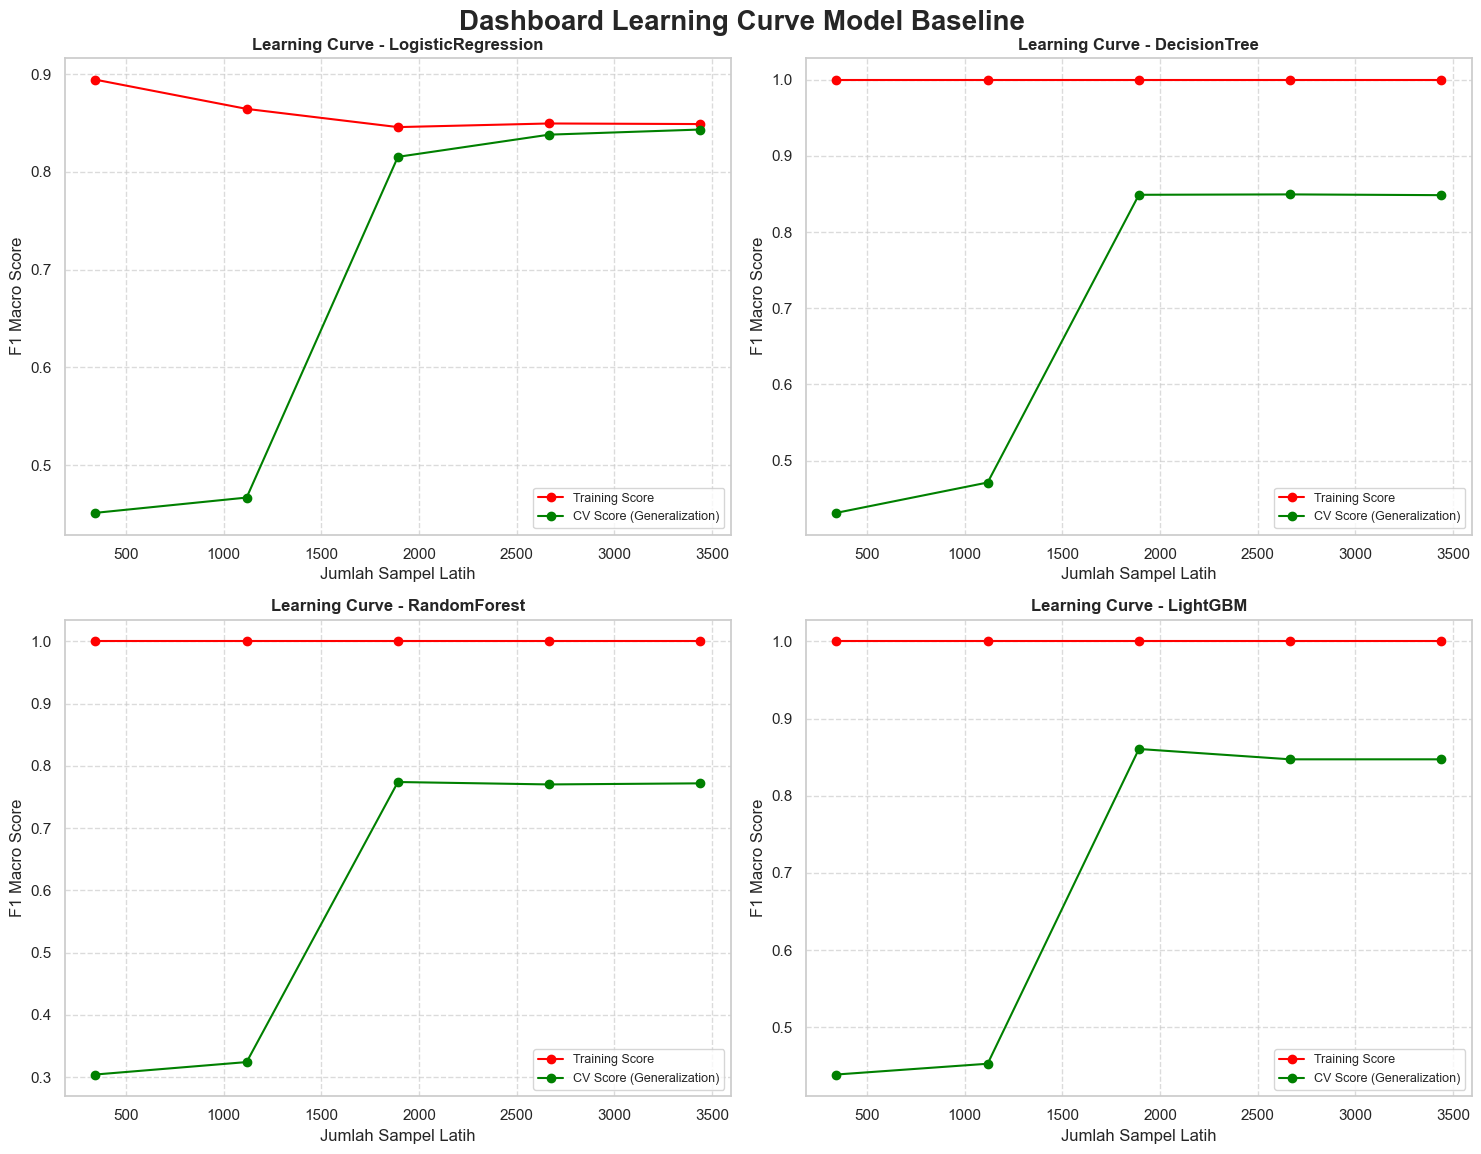


REKAPITULASI SKOR F1-MACRO BASELINE
 - LightGBM: 0.9739
 - DecisionTree: 0.9526
 - RandomForest: 0.8848
 - LogisticRegression: 0.8759


In [6]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

print("=== Modul Visualisasi: Membuat Dashboard Learning Curve ===\n")

# Buat folder sementara untuk menyimpan gambar sebelum dikirim ke MLflow
os.makedirs("mlflow_plots", exist_ok=True)

# Menghitung jumlah model untuk membuat grid yang dinamis
n_models = len(models_to_compare)
cols = 2
rows = math.ceil(n_models / cols)

# Siapkan Kanvas
fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
fig.suptitle("Dashboard Learning Curve Model Baseline", fontsize=20, fontweight='bold', y=0.96)

# Ratakan axes (flatten) agar mudah diiterasi menggunakan index 1D
axes = axes.flatten()

for idx, model_name in enumerate(models_to_compare.keys()):
    # Ambil pipeline yang sudah dilatih dari memori
    pipeline = trained_pipelines[model_name]
    
    ax = axes[idx]
    
    # Kalkulasi Learning Curve
    train_sizes, train_scores, test_scores = learning_curve(
        pipeline, X, y_encoded, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1_macro'
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    # Plotting
    ax.plot(train_sizes, train_scores_mean, 'o-', color="red", label="Training Score")
    ax.plot(train_sizes, test_scores_mean, 'o-', color="green", label="CV Score (Generalization)")
    ax.set_xlabel("Jumlah Sampel Latih")
    ax.set_ylabel("F1 Macro Score")
    ax.set_title(f'Learning Curve - {model_name}', fontweight='bold')
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.7)

# Jika jumlah model ganjil, hapus subplot kosong yang tersisa di akhir
for i in range(n_models, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Beri ruang untuk judul utama

# Simpan dashboard gabungan ini sebagai satu gambar
dashboard_path = "mlflow_plots/baseline_learning_curves.png"
plt.savefig(dashboard_path)
print(f"Dashboard disimpan di {dashboard_path}")
plt.show()

print("\n" + "="*50)
print("REKAPITULASI SKOR F1-MACRO BASELINE")
print("="*50)
for model, score in sorted(model_scores.items(), key=lambda x: x[1], reverse=True):
    print(f" - {model}: {score:.4f}")
print("="*50)

## Model Selection

In [7]:
# ==============================================================================
# KEPUTUSAN ARSITEKTUR: PEMILIHAN MODEL BASELINE
# ==============================================================================


chosen_model_name = "LightGBM"  # <-- Anda bisa mengubah ini berdasarkan interpretasi grafik Anda

print(f"Model baseline terpilih untuk di-tune: {chosen_model_name}")

# Panggil model pemenang dari memori
best_baseline_model = trained_pipelines[chosen_model_name]

Model baseline terpilih untuk di-tune: LightGBM


## Tuning

In [8]:
!pip install shap


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
!pip install optuna


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



Memulai Evolusi Tuning Anti-Overfitting dengan Optuna untuk LightGBM...


Best trial: 41. Best value: 0.890777: 100%|██████████| 50/50 [01:12<00:00,  1.46s/it]
2026/06/10 04:01:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/10 04:01:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



EVALUASI MODEL FINAL: LightGBM (Optuna Tuned)
Waktu Tuning: 72.84 detik
Best CV Score dari Optuna: 0.8908
Parameter Terbaik Penakluk Overfitting:
 {'n_estimators': 386, 'learning_rate': 0.018693345025273832, 'max_depth': 4, 'num_leaves': 13, 'min_child_samples': 54, 'reg_alpha': 1.5754898704855933, 'reg_lambda': 2.277642748053603, 'subsample': 0.5829262536627436, 'colsample_bytree': 0.6957724781707468, 'min_split_gain': 0.35313041224835345}

1. CLASSIFICATION REPORT
                       precision    recall  f1-score   support

      Highly Suitable       1.00      1.00      1.00       560
Restricted / Stressed       0.99      0.96      0.98       258
             Suitable       0.80      0.95      0.87        39
Unsuitable / Critical       0.75      1.00      0.86         3

             accuracy                           0.99       860
            macro avg       0.89      0.98      0.93       860
         weighted avg       0.99      0.99      0.99       860



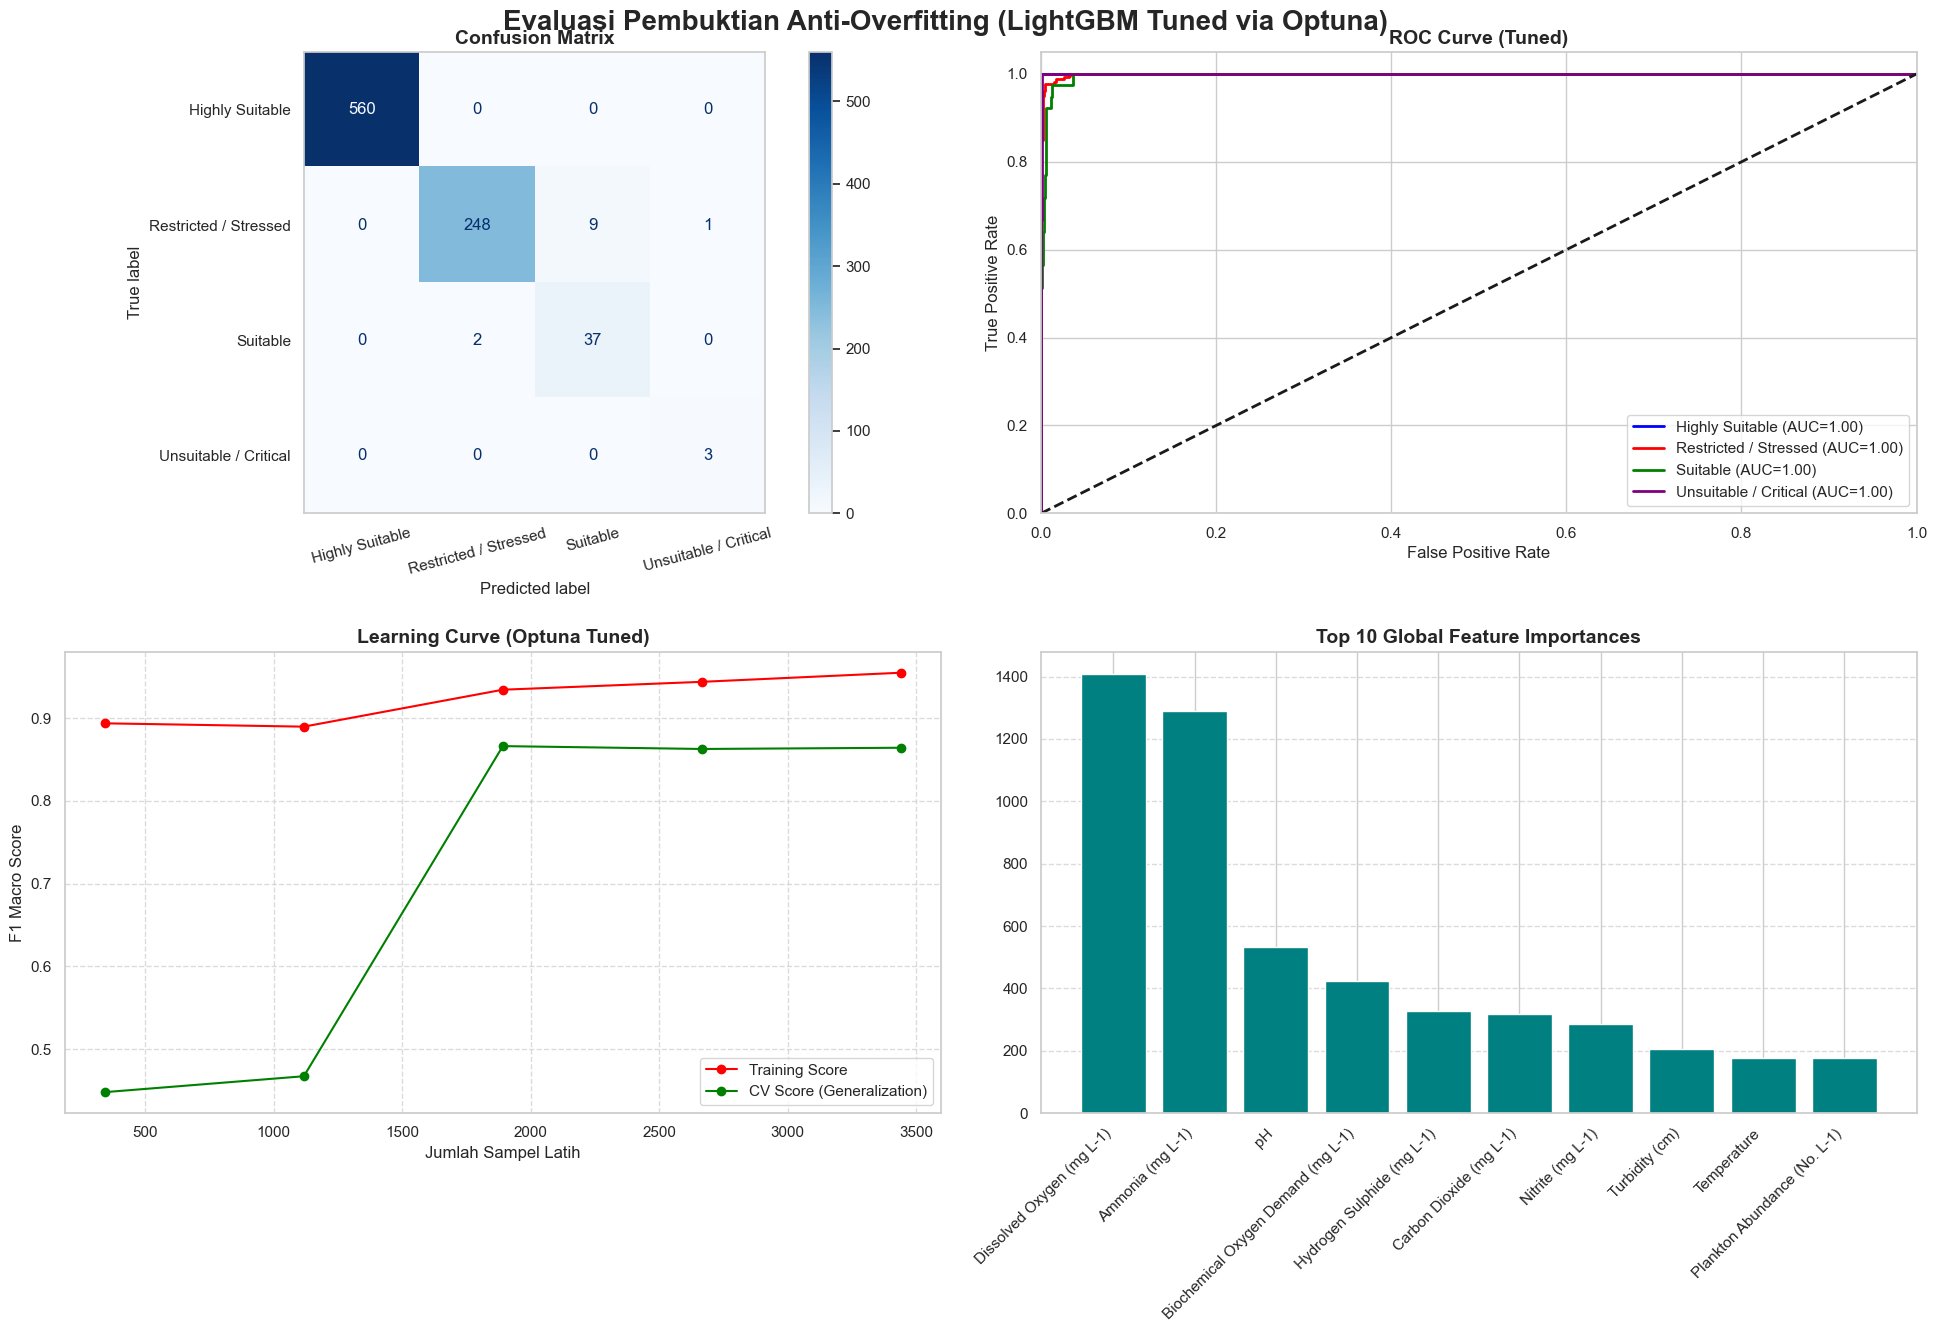


[INFO] Mengekstraksi dan Membangun SHAP Summary Plot...


<Figure size 1000x600 with 0 Axes>

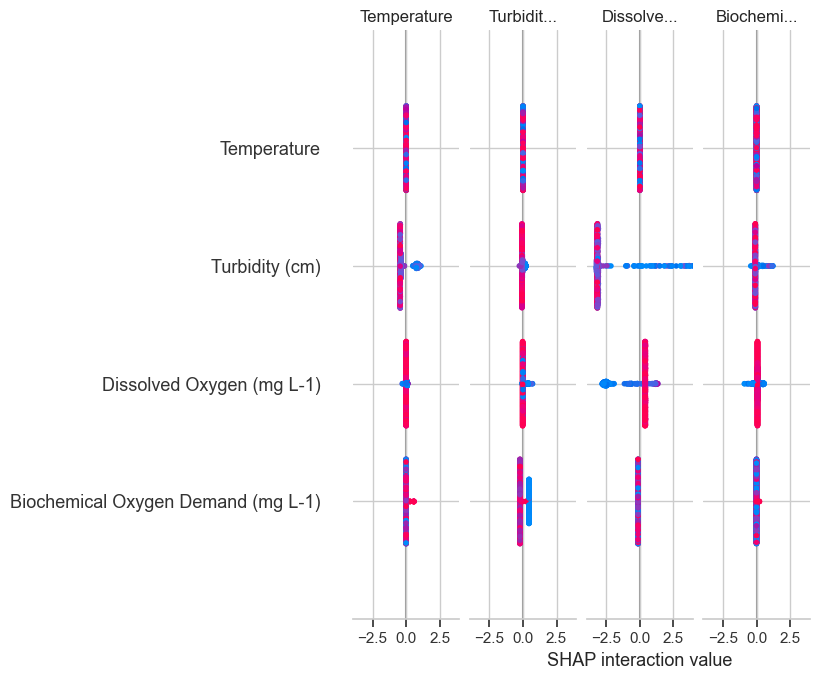

🏃 View run Tuned_LightGBM_Optuna at: http://127.0.0.1:5000/#/experiments/1/runs/d36262717c304381b6e2d694222fce98
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [11]:
import optuna
import mlflow
import mlflow.sklearn
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, auc, accuracy_score, f1_score
import shap

# Pastikan Anda sudah mengimpor model-model ini di awal notebook
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Matikan log Optuna agar tidak memenuhi output (hanya tampilkan progress bar)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Anda bisa mengganti ini dengan "RandomForest" atau "XGBoost" kapan saja
chosen_model_name = "LightGBM" 
print(f"\nMemulai Evolusi Tuning Anti-Overfitting dengan Optuna untuk {chosen_model_name}...")

# ==============================================================================
# 1. DEFINISI FUNGSI OBJEKTIF OPTUNA (DENGAN LOGIKA IF-ELSE)
# ==============================================================================
def objective(trial):
    if chosen_model_name == "LightGBM":
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 150, 400),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),  # Lebih rendah
            'max_depth': trial.suggest_int('max_depth', 3, 5),            # Cap 5, bukan 7
            'num_leaves': trial.suggest_int('num_leaves', 7, 24),         # Turunkan maks
            'min_child_samples': trial.suggest_int('min_child_samples', 40, 120),  # Naikkan min
            'reg_alpha': trial.suggest_float('reg_alpha', 1.0, 15.0),     # Jauh lebih tinggi
            'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 15.0),   # Jauh lebih tinggi
            'subsample': trial.suggest_float('subsample', 0.5, 0.7),      # Paksa rendah
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.7),  # Paksa rendah
            'min_split_gain': trial.suggest_float('min_split_gain', 0.01, 0.5),  # BARU: cegah split remeh
            'class_weight': 'balanced',
            'random_state': 42,
            'n_jobs': -1,
            'verbose': -1
        }
        clf = LGBMClassifier(**params)

        
    elif chosen_model_name == "RandomForest":
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300),
            'max_depth': trial.suggest_int('max_depth', 5, 15),
            'min_samples_split': trial.suggest_int('min_samples_split', 10, 50),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 20),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            'class_weight': 'balanced',
            'random_state': 42,
            'n_jobs': -1
        }
        clf = RandomForestClassifier(**params)
        
    elif chosen_model_name == "XGBoost":
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'min_child_weight': trial.suggest_int('min_child_weight', 3, 10),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 5.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 5.0, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'random_state': 42,
            'use_label_encoder': False,
            'eval_metric': 'mlogloss',
            'n_jobs': -1
        }
        clf = XGBClassifier(**params)
        
    else:
        raise ValueError(f"Model {chosen_model_name} belum dikonfigurasi di dalam Optuna Objective.")

    # Bangun Pipeline untuk evaluasi CV
    pipeline = Pipeline([
        ('scaler', RobustScaler()),
        ('classifier', clf)
    ])
    
    # Evaluasi menggunakan Cross Validation
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

# ==============================================================================
# 2. EKSEKUSI OPTUNA STUDY & MLFLOW TRACKING
# ==============================================================================
with mlflow.start_run(run_name=f"Tuned_{chosen_model_name}_Optuna"):
    
    start_tune_time = time.time()
    
    # Inisialisasi dan jalankan pencarian (maximize F1 Macro)
    study = optuna.create_study(direction='maximize', study_name=f"{chosen_model_name}_Optimization")
    study.optimize(objective, n_trials=50, show_progress_bar=True) # Set iterasi pencarian cerdas di sini
    
    tuning_time = time.time() - start_tune_time
    
    # ---------------------------------------------------------
    # MEMBANGUN ULANG MODEL TERBAIK (RE-INSTANTIATION)
    # ---------------------------------------------------------
    best_params = study.best_params
    
    if chosen_model_name == "LightGBM":
        final_clf = LGBMClassifier(**best_params, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
    elif chosen_model_name == "RandomForest":
        final_clf = RandomForestClassifier(**best_params, class_weight='balanced', random_state=42, n_jobs=-1)
    elif chosen_model_name == "XGBoost":
        final_clf = XGBClassifier(**best_params, random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)
        
    best_tuned_pipeline = Pipeline([
        ('scaler', RobustScaler()),
        ('classifier', final_clf)
    ])
    
    # Latih model terbaik dengan seluruh data latih
    best_tuned_pipeline.fit(X_train, y_train)
    
    # Prediksi
    y_pred_tuned = best_tuned_pipeline.predict(X_test)
    y_score_tuned = best_tuned_pipeline.predict_proba(X_test)
    
    acc_tuned = accuracy_score(y_test, y_pred_tuned)
    f1_tuned = f1_score(y_test, y_pred_tuned, average='macro')
    
    # Logging MLflow
    mlflow.log_params(best_params)
    mlflow.log_metric("accuracy", acc_tuned)
    mlflow.log_metric("f1_macro", f1_tuned)
    mlflow.log_metric("optuna_best_cv", study.best_value)
    mlflow.log_metric("tuning_time_seconds", tuning_time)
    mlflow.sklearn.log_model(best_tuned_pipeline, "production_ready_model")
    
    print("\n" + "="*60)
    print(f"EVALUASI MODEL FINAL: {chosen_model_name} (Optuna Tuned)")
    print("="*60)
    print(f"Waktu Tuning: {tuning_time:.2f} detik")
    print(f"Best CV Score dari Optuna: {study.best_value:.4f}")
    print("Parameter Terbaik Penakluk Overfitting:\n", best_params)
    
    print("\n1. CLASSIFICATION REPORT")
    print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

# ==========================================
    # VISUALISASI KOMPREHENSIF (4 Panel)
    # ==========================================
    # Menggunakan kanvas yang jauh lebih besar agar 4 grafik tidak berdesakan
    fig_tuned, axes_tuned = plt.subplots(2, 2, figsize=(20, 14)) 
    fig_tuned.suptitle(f"Evaluasi Pembuktian Anti-Overfitting ({chosen_model_name} Tuned via Optuna)", fontsize=20, fontweight='bold', y=0.95)

    # -----------------------------------------------------
    # PLOT A: Confusion Matrix
    # -----------------------------------------------------
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_tuned, 
        display_labels=le.classes_, 
        cmap='Blues', ax=axes_tuned[0, 0], xticks_rotation=15
    )
    axes_tuned[0, 0].set_title("Confusion Matrix", fontweight='bold', fontsize=14)
    axes_tuned[0, 0].grid(False)

    # -----------------------------------------------------
    # PLOT B: Multi-class ROC-AUC
    # -----------------------------------------------------
    colors = ['blue', 'red', 'green', 'purple']
    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_tuned[:, i])
        roc_auc = auc(fpr, tpr)
        axes_tuned[0, 1].plot(fpr, tpr, color=color, lw=2, label=f"{le.classes_[i]} (AUC={roc_auc:.2f})")

    axes_tuned[0, 1].plot([0, 1], [0, 1], 'k--', lw=2)
    axes_tuned[0, 1].set_xlim([0.0, 1.0])
    axes_tuned[0, 1].set_ylim([0.0, 1.05])
    axes_tuned[0, 1].set_xlabel('False Positive Rate', fontsize=12)
    axes_tuned[0, 1].set_ylabel('True Positive Rate', fontsize=12)
    axes_tuned[0, 1].set_title('ROC Curve (Tuned)', fontweight='bold', fontsize=14)
    axes_tuned[0, 1].legend(loc="lower right", fontsize=11)

    # -----------------------------------------------------
    # PLOT C: Learning Curve (Evaluasi Gap Overfitting)
    # -----------------------------------------------------
    train_sizes, train_scores, test_scores = learning_curve(
        best_tuned_pipeline, X, y_encoded, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1_macro'
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    axes_tuned[1, 0].plot(train_sizes, train_scores_mean, 'o-', color="red", label="Training Score")
    axes_tuned[1, 0].plot(train_sizes, test_scores_mean, 'o-', color="green", label="CV Score (Generalization)")
    axes_tuned[1, 0].set_xlabel("Jumlah Sampel Latih", fontsize=12)
    axes_tuned[1, 0].set_ylabel("F1 Macro Score", fontsize=12)
    axes_tuned[1, 0].set_title('Learning Curve (Optuna Tuned)', fontweight='bold', fontsize=14)
    axes_tuned[1, 0].legend(loc="lower right", fontsize=11)
    axes_tuned[1, 0].grid(True, linestyle='--', alpha=0.7)

    # -----------------------------------------------------
    # PLOT D: Feature Importance Global (Dibatasi Top 10)
    # -----------------------------------------------------
    importances = final_clf.feature_importances_
    indices = np.argsort(importances)[::-1]

    top_n = min(10, len(indices))
    
    axes_tuned[1, 1].bar(range(top_n), importances[indices][:top_n], align="center", color='teal')
    axes_tuned[1, 1].set_xticks(range(top_n))
    axes_tuned[1, 1].set_xticklabels(X.columns[indices][:top_n], rotation=45, ha='right', fontsize=11)
    axes_tuned[1, 1].set_title("Top 10 Global Feature Importances", fontweight='bold', fontsize=14)
    axes_tuned[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

    # Rendering Final Layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.3)
    
    # Simpan dan catat grafik utama ke MLflow
    import os
    os.makedirs("mlflow_plots", exist_ok=True)
    eval_path = "mlflow_plots/final_optuna_evaluation.png"
    plt.savefig(eval_path, bbox_inches='tight')
    mlflow.log_artifact(eval_path)
    plt.show()

    # ==========================================
    # SHAP VALUES (Interpretasi Model - Berdiri Sendiri)
    # ==========================================
    print("\n[INFO] Mengekstraksi dan Membangun SHAP Summary Plot...")
    scaler_model = best_tuned_pipeline.named_steps['scaler']
    X_test_scaled = scaler_model.transform(X_test)
    
    explainer = shap.TreeExplainer(final_clf)
    shap_values = explainer.shap_values(X_test_scaled)
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, feature_names=X.columns, class_names=le.classes_, show=False)
    
    shap_path = "mlflow_plots/shap_summary_optuna.png"
    plt.savefig(shap_path, bbox_inches='tight')
    mlflow.log_artifact(shap_path)
    plt.show()